Preprocessing i Autorska Inżynieria Cech (Feature Engineering).
Wymiarowość macierzy po dodaniu cech autorskich: (175341, 195)

Macierz korelacji Pearsona (PCC).
Wygenerowano: 'Wykres_1_PCC_Correlation.png'.

Rekursywna eliminacja cech (RFECV).
Rozpoczęto dopasowywanie modelu RFECV.
Zidentyfikowana optymalna liczba cech: 33
Wygenerowano: 'Wykres_2_RFECV_Fig3.png'.

Interpretowalność modelu i estymacja Shapley'a (SHAP).
Wygenerowano wykres wieloklasowy SHAP: 'Wykres_3_SHAP_Summary_MultiClass.png'.


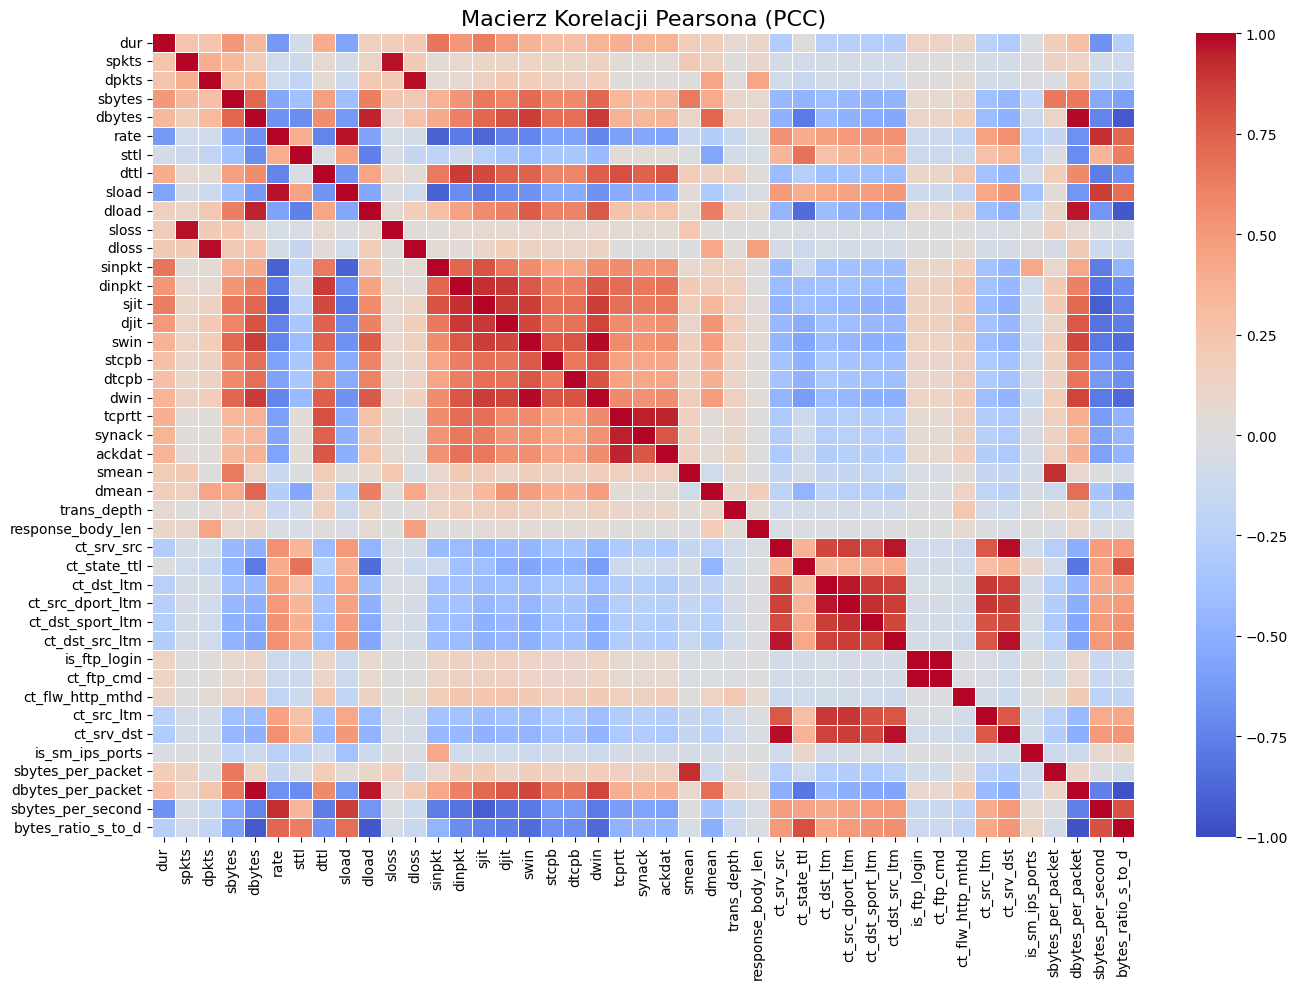

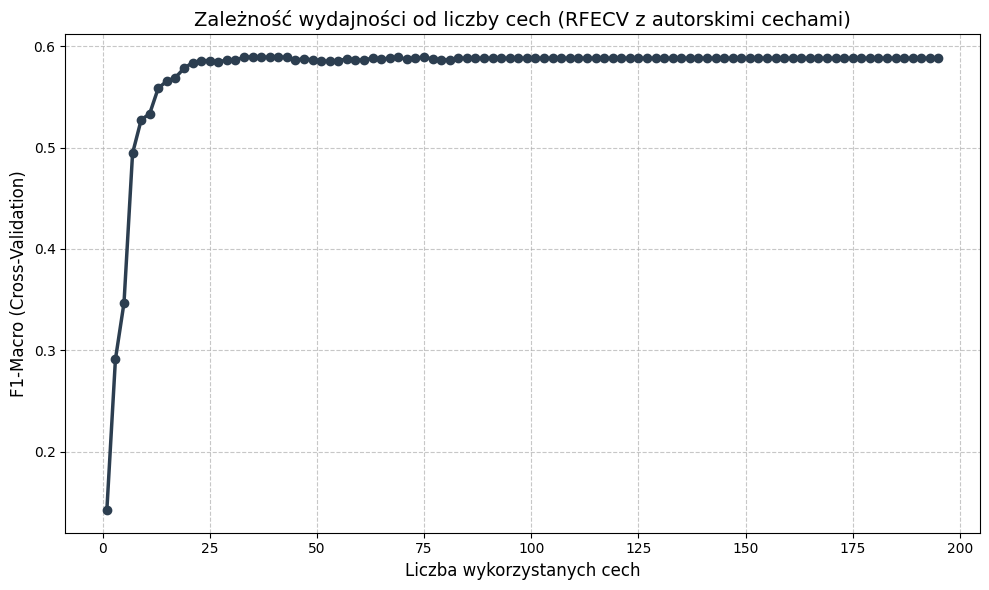

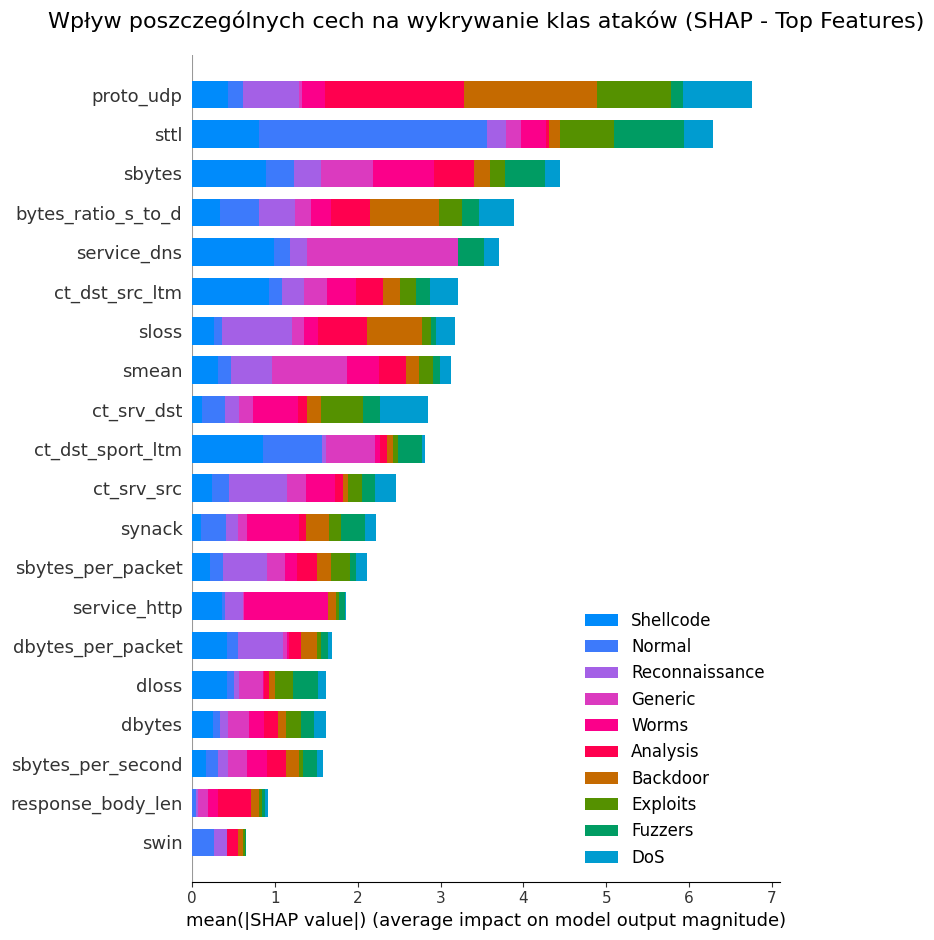

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold
from xgboost import XGBClassifier
import shap

# Redukcja ostrzeżeń środowiskowych
warnings.filterwarnings('ignore')

print("Preprocessing i Autorska Inżynieria Cech (Feature Engineering).")
df_train = pd.read_csv('UNSW_NB15_training-set.csv')
df_clean = df_train.drop(columns=['id', 'label'], errors='ignore')

df_clean['sbytes_per_packet'] = df_clean['sbytes'] / (df_clean['spkts'] + 1e-5)
df_clean['dbytes_per_packet'] = df_clean['dbytes'] / (df_clean['dpkts'] + 1e-5)
df_clean['sbytes_per_second'] = df_clean['sbytes'] / (df_clean['dur'] + 1e-5)
df_clean['bytes_ratio_s_to_d'] = df_clean['sbytes'] / (df_clean['dbytes'] + 1e-5)

skewed_features = [
    'sbytes', 'dbytes', 'dur', 'rate', 'sload', 'dload', 'sjit', 'djit', 'sinpkt', 'dinpkt', 
    'sbytes_per_packet', 'dbytes_per_packet', 'sbytes_per_second', 'bytes_ratio_s_to_d'
]

for col in skewed_features:
    if col in df_clean.columns:
        df_clean[col] = np.log1p(df_clean[col])

X = df_clean.drop(columns=['attack_cat'])
y = df_clean['attack_cat']

le = LabelEncoder()
y_encoded = le.fit_transform(y)
nazwy_klas = le.classes_

categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_encoded), columns=X_encoded.columns)

print(f"Wymiarowość macierzy po dodaniu cech autorskich: {X_scaled.shape}")

# ==============================================================================
print("\nMacierz korelacji Pearsona (PCC).")
numeric_only = df_clean.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df_clean[numeric_only].corr(method='pearson')

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Macierz Korelacji Pearsona (PCC)', fontsize=16)
plt.tight_layout()
plt.savefig('Wykres_1_PCC_Correlation.png')
print("Wygenerowano: 'Wykres_1_PCC_Correlation.png'.")

# ==============================================================================
print("\nRekursywna eliminacja cech (RFECV).")

np.random.seed(42)
#sample_indices = np.random.choice(X_scaled.index, size=20000, replace=False)
#X_sample = X_scaled.loc[sample_indices]
#y_sample = y_encoded[sample_indices]
X_sample = X_scaled
y_sample = y_encoded
xgb = XGBClassifier(
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=5, 
    eval_metric='mlogloss',
    n_jobs=-1,
    random_state=42
)

# Konfiguracja 3-krotnej walidacji krzyżowej z krokiem eliminacji n=2
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
rfecv = RFECV(estimator=xgb, step=2, cv=cv, scoring='f1_macro', n_jobs=-1)

print("Rozpoczęto dopasowywanie modelu RFECV.")
rfecv.fit(X_sample, y_sample)

plt.figure(figsize=(10, 6))
plt.xlabel("Liczba wykorzystanych cech", fontsize=12)
plt.ylabel("F1-Macro (Cross-Validation)", fontsize=12)
plt.title("Zależność wydajności od liczby cech (RFECV z autorskimi cechami)", fontsize=14)

scores = rfecv.cv_results_['mean_test_score'] if hasattr(rfecv, 'cv_results_') else rfecv.grid_scores_
num_features = range(1, len(scores) * 2 + 1, 2) 

plt.plot(num_features[:len(scores)], scores, color='#2c3e50', linewidth=2.5, marker='o')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('Wykres_2_RFECV_Fig3.png')
print(f"Zidentyfikowana optymalna liczba cech: {rfecv.n_features_}")
print("Wygenerowano: 'Wykres_2_RFECV_Fig3.png'.")
#SHAP DLA ZBIORU TESTOWEGO(BEZ SHAP)
# ==============================================================================
print("\nInterpretowalność modelu i estymacja Shapley'a (SHAP).")
X_optimal = X_sample.loc[:, rfecv.support_]
X_optimal_sample = X_optimal.sample(n=1000, random_state=42)

# Ponowne trenowanie estymatora na wyselekcjonowanej przestrzeni 
xgb_final = XGBClassifier(n_estimators=100, max_depth=5, eval_metric='mlogloss', n_jobs=-1, random_state=42)
xgb_final.fit(X_optimal, y_sample)

explainer = shap.TreeExplainer(xgb_final)
shap_values = explainer.shap_values(X_optimal_sample)

plt.figure(figsize=(14, 10))

# --- POPRAWKA RENDEROWANIA DLA MULTI-CLASS SHAP (Wymuszenie Stacked Bar Plot) ---
if isinstance(shap_values, np.ndarray) and len(shap_values.shape) == 3:
    shap_values_list = [shap_values[:, :, i] for i in range(shap_values.shape[2])]
    shap.summary_plot(shap_values_list, X_optimal_sample, plot_type="bar", show=False, class_names=nazwy_klas)
elif isinstance(shap_values, list):
    shap.summary_plot(shap_values, X_optimal_sample, plot_type="bar", show=False, class_names=nazwy_klas)
else:
    shap.summary_plot(shap_values, X_optimal_sample, show=False)

plt.title("Wpływ poszczególnych cech na wykrywanie klas ataków (SHAP - Top Features)", fontsize=16, pad=20)
plt.tight_layout()
plt.savefig('Wykres_3_SHAP_Summary_MultiClass.png')
print("Wygenerowano wykres wieloklasowy SHAP: 'Wykres_3_SHAP_Summary_MultiClass.png'.")

In [5]:
#jeśli lista optimal features sie różni od używanych poniżej to zamienić ją na tą
lista_cech = X_optimal.columns.tolist()
print("\n" + "="*80)
print(f"optimal_features = {lista_cech}")
print("="*80 + "\n")


optimal_features = ['dpkts', 'sbytes', 'dbytes', 'sttl', 'dttl', 'sloss', 'dloss', 'swin', 'synack', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'ct_srv_dst', 'sbytes_per_packet', 'dbytes_per_packet', 'sbytes_per_second', 'bytes_ratio_s_to_d', 'proto_arp', 'proto_icmp', 'proto_igmp', 'proto_sep', 'proto_udp', 'proto_unas', 'service_dns', 'service_ftp-data', 'service_http', 'service_snmp', 'state_INT']



In [11]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from sklearn.model_selection import cross_val_predict
from tensorflow.keras.layers import Dense, LeakyReLU, BatchNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from collections import Counter
import warnings
import os
import random

seed_value = 42
os.environ['PYTHONHASHSEED'] = str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' 

def build_generator(latent_dim, output_dim):
    model = Sequential([
        Dense(128, input_dim=latent_dim),
        LeakyReLU(alpha=0.2),
        BatchNormalization(),
        Dense(256),
        LeakyReLU(alpha=0.2),
        BatchNormalization(),
        Dense(output_dim, activation='sigmoid')
    ], name="Generator")
    return model

def build_discriminator(input_dim):
    model = Sequential([
        Dense(256, input_dim=input_dim),
        LeakyReLU(alpha=0.2),
        Dense(128),
        LeakyReLU(alpha=0.2),
        Dense(1, activation='sigmoid')
    ], name="Discriminator")
    model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.0002, beta_1=0.5), metrics=['accuracy'])
    return model

def build_gan(generator, discriminator):
    discriminator.trainable = False
    model = Sequential([generator, discriminator], name="GAN")
    model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.0002, beta_1=0.5))
    return model

def run_gan_augmentation():
    print("Inicjalizacja zbioru i autorska inżynieria cech...")
    df_train = pd.read_csv('UNSW_NB15_training-set.csv')
    df_clean = df_train.drop(columns=['id', 'label'], errors='ignore')

    df_clean['sbytes_per_packet'] = df_clean['sbytes'] / (df_clean['spkts'] + 1e-5)
    df_clean['dbytes_per_packet'] = df_clean['dbytes'] / (df_clean['dpkts'] + 1e-5)
    df_clean['sbytes_per_second'] = df_clean['sbytes'] / (df_clean['dur'] + 1e-5)
    df_clean['bytes_ratio_s_to_d'] = df_clean['sbytes'] / (df_clean['dbytes'] + 1e-5)

    optimal_features = ['dpkts', 'sbytes', 'dbytes', 'sttl', 'dttl', 'sloss', 'dloss',
                        'swin', 'synack', 'smean', 'dmean', 'trans_depth', 'response_body_len',
                        'ct_srv_src', 'ct_state_ttl', 'ct_dst_sport_ltm', 'ct_dst_src_ltm',
                        'ct_srv_dst', 'sbytes_per_packet', 'dbytes_per_packet', 'sbytes_per_second',
                        'bytes_ratio_s_to_d', 'proto_arp', 'proto_icmp', 'proto_igmp', 'proto_sep',
                        'proto_udp', 'proto_unas', 'service_dns', 'service_ftp-data', 'service_http',
                        'service_snmp', 'state_INT']
    
   
    skewed_features = [
        'sbytes', 'dbytes', 'dur', 'rate', 'sload', 'dload', 'sjit', 'djit', 'sinpkt', 'dinpkt', 
        'sbytes_per_packet', 'dbytes_per_packet', 'sbytes_per_second', 'bytes_ratio_s_to_d'
    ]
    
    for col in skewed_features:
        if col in df_clean.columns:
            df_clean[col] = np.log1p(df_clean[col])

    y = df_clean['attack_cat']
    X = df_clean.drop(columns=['attack_cat'])

    le = LabelEncoder()
    y_encoded = le.fit_transform(y.str.strip().str.lower().replace('backdoors', 'backdoor'))

    categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
    X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=False)

    missing_cols = [col for col in optimal_features if col not in X_encoded.columns]
    if missing_cols:
        missing_df = pd.DataFrame(0, index=X_encoded.index, columns=missing_cols)
        X_encoded = pd.concat([X_encoded, missing_df], axis=1)
            
    X_optimal = X_encoded[optimal_features]

    scaler = MinMaxScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X_optimal), columns=X_optimal.columns)

    print(f"Wymiarowość macierzy po selekcji: {X_scaled.shape}")

    print("Izolacja Zbioru Trudnego (DSSTE)...")
    knn = KNeighborsClassifier(n_neighbors=1, algorithm='kd_tree', n_jobs=1)
    y_pred_knn = cross_val_predict(knn, X_scaled, y_encoded, cv=5, n_jobs=1)
    difficult_indices = np.where(y_encoded != y_pred_knn)[0]
    #knn.fit(X_scaled, y_encoded)
    #y_pred_knn = knn.predict(X_scaled)

    difficult_indices = np.where(y_encoded != y_pred_knn)[0]
    
    TARGET_SAMPLES = 10000 
    latent_dim = 50
    output_dim = X_scaled.shape[1]

    synthetic_X = []
    synthetic_y = []

    class_counts = Counter(y_encoded)
    minority_classes = [cls for cls, count in class_counts.items() if count < TARGET_SAMPLES]

    print("\nRozpoczęcie syntezy danych (GAN)...")
    for cls in minority_classes:
        num_samples = TARGET_SAMPLES - class_counts[cls]
        print(f" -> Generacja dla klasy: {le.inverse_transform([cls])[0]} | Cel: {num_samples} szt.")
        
        cls_difficult_idx = [i for i in difficult_indices if y_encoded[i] == cls]
        if len(cls_difficult_idx) < 10: 
            real_data = X_scaled[y_encoded == cls].values
        else:
            real_data = X_scaled.iloc[cls_difficult_idx].values
            
        generator = build_generator(latent_dim, output_dim)
        discriminator = build_discriminator(output_dim)
        gan = build_gan(generator, discriminator)
        
        epochs = 500 
        batch_size = min(32, len(real_data))
        
        for epoch in range(epochs):
            idx = np.random.randint(0, real_data.shape[0], batch_size)
            real_samples = real_data[idx]
            noise = np.random.normal(0, 1, (batch_size, latent_dim))
            fake_samples = generator.predict(noise, verbose=0)
            
            discriminator.train_on_batch(real_samples, np.ones((batch_size, 1)))
            discriminator.train_on_batch(fake_samples, np.zeros((batch_size, 1)))
            
            noise = np.random.normal(0, 1, (batch_size, latent_dim))
            gan.train_on_batch(noise, np.ones((batch_size, 1)))
            
        noise = np.random.normal(0, 1, (num_samples, latent_dim))
        generated_data = generator.predict(noise, verbose=0)
        
        synthetic_X.append(pd.DataFrame(generated_data, columns=X_scaled.columns))
        synthetic_y.extend([cls] * num_samples)

    if len(synthetic_X) > 0:
        X_synthetic_df = pd.concat(synthetic_X, ignore_index=True)
        y_synthetic_df = pd.Series(synthetic_y)
        
        X_train_balanced = pd.concat([X_scaled, X_synthetic_df], ignore_index=True)
        y_train_balanced = pd.concat([pd.Series(y_encoded), y_synthetic_df], ignore_index=True)
        
        balanced_df = X_train_balanced.copy()
        balanced_df['target_class'] = y_train_balanced
        balanced_df.to_csv('UNSW_NB15_GAN_Balanced_main.csv', index=False)
        print("\nEksport zbalansowanego zbioru do pliku: 'UNSW_NB15_GAN_Balanced_main.csv'")

run_gan_augmentation()

Inicjalizacja zbioru i autorska inżynieria cech...
Wymiarowość macierzy po selekcji: (175341, 33)
Izolacja Zbioru Trudnego (DSSTE)...

Rozpoczęcie syntezy danych (GAN)...
 -> Generacja dla klasy: backdoor | Cel: 8254 szt.
 -> Generacja dla klasy: analysis | Cel: 8000 szt.
 -> Generacja dla klasy: shellcode | Cel: 8867 szt.
 -> Generacja dla klasy: worms | Cel: 9870 szt.

Eksport zbalansowanego zbioru do pliku: 'UNSW_NB15_GAN_Balanced_main.csv'


In [ ]:
#SHAP DLA ZBIORU GAN

In [9]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
import warnings

warnings.filterwarnings('ignore')

def run_comprehensive_feature_analysis():
    
    CLASS_MAPPING = {
        0: 'Normal',
        1: 'Analysis',
        2: 'Backdoor',
        3: 'DoS',
        4: 'Exploits',
        5: 'Fuzzers',
        6: 'Generic',
        7: 'Reconnaissance',
        8: 'Shellcode',
        9: 'Worms'
    }

    print("[INFO] Ładowanie zbalansowanego zbioru GAN...")
    df_full = pd.read_csv('UNSW_NB15_GAN_Balanced_main.csv')
    
    optimal_features = ['dpkts', 'sbytes', 'dbytes', 'sttl', 'dttl', 'sloss', 'dloss', 'swin',
                        'synack', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src',
                        'ct_state_ttl', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'ct_srv_dst', 'sbytes_per_packet',
                        'dbytes_per_packet', 'sbytes_per_second', 'bytes_ratio_s_to_d', 'proto_arp', 'proto_icmp',
                        'proto_igmp', 'proto_sep', 'proto_udp', 'proto_unas', 'service_dns', 'service_ftp-data',
                        'service_http', 'service_snmp', 'state_INT']
        
    X = df_full[optimal_features]
    y = df_full['target_class']
    
    print("Trening XGBoost na zbalansowanych danych...")
    model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, 
                          objective='multi:softprob', num_class=10, 
                          n_jobs=-1, random_state=42)
    model.fit(X, y)

    gain_importances = model.feature_importances_
    
    print("Generowanie wartości SHAP...")
    X_sample = X.sample(frac=0.1, random_state=42)
    
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_sample)
    
    if isinstance(shap_values, list):
        shap_values_abs = np.abs(shap_values).mean(axis=0)
    elif len(shap_values.shape) == 3:
        shap_values_abs = np.abs(shap_values).mean(axis=2)
    else:
        shap_values_abs = np.abs(shap_values)

    mean_shap_values = shap_values_abs.mean(axis=0)
    
    feature_metrics_df = pd.DataFrame({
        'Atrybut': X.columns,
        'SHAP_Value': mean_shap_values,
        'Information_Gain': gain_importances
    }).sort_values(by='SHAP_Value', ascending=False).reset_index(drop=True)
    
    feature_metrics_df.to_csv('Analiza_Cech_SHAP_vs_Gain_main.csv', index=False)
    
    target_classes = model.classes_
    class_names_list = [CLASS_MAPPING.get(int(c), f"Klasa {int(c)}") for c in target_classes]

    print("Zapisywanie wykresów...")
    plt.figure(figsize=(12, 10), dpi=300)
    shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False, 
                      max_display=33, class_names=class_names_list)
    plt.title('Wyjaśnialność modelu (XAI): Wartości SHAP po balansowaniu GAN', fontsize=14)
    plt.xlabel('Średni absolutny wpływ (SHAP Value)', fontsize=12)
    plt.tight_layout()
    plt.savefig('Wykres_SHAP_33_Cech_Po_GAN.png', bbox_inches='tight')
    plt.close()

    plt.figure(figsize=(12, 12), dpi=300)
    plot_df = feature_metrics_df.sort_values(by='Information_Gain', ascending=True)
    
    bars = plt.barh(plot_df['Atrybut'], plot_df['Information_Gain'], color='#2ecc71', edgecolor='black')
    plt.title('Wewnętrzna ocena modelu: Zysk Informacyjny (Po GAN)', fontsize=14)
    plt.xlabel('Względny udział atrybutu (Gain)', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig('Wykres_Gain_33_Cech_Po_GAN.png', bbox_inches='tight')
    plt.close()
    
    print("Wygenerowano pliki: Analiza_Cech_SHAP_vs_Gain_main.csv, Wykres_SHAP_33_Cech_Po_GAN.png, Wykres_Gain_33_Cech_Po_GAN.png")

run_comprehensive_feature_analysis()

[INFO] Ładowanie zbalansowanego zbioru GAN...
Trening XGBoost na zbalansowanych danych...
Generowanie wartości SHAP...
Zapisywanie wykresów...
Wygenerowano pliki: Analiza_Cech_SHAP_vs_Gain_main.csv, Wykres_SHAP_33_Cech_Po_GAN.png, Wykres_Gain_33_Cech_Po_GAN.png
